# Social Media Engagement — Explanatory (OLS) Pipeline

**Business question:** Among *actionable* post choices (platform, timing, format, caption, CTA, topic, boost), which attributes are associated with higher `engagement_rate`? Audience-scale drivers (impressions, follower counts) are excluded so results speak to what staff can change when composing a post.

**Modeling goal — Explanation (Ch. 9–10):** Multiple linear regression with interpretable coefficients; **diagnostics** (VIF on continuous inputs, residual plot, Durbin–Watson). Associations are **not** causal proof.

**Full pipeline in this notebook:** load data → EDA → feature engineering → OLS → diagnostics → export `SeedData/social_engagement_insights.json`.

**Production sync:** Feature definitions mirror `ml_scripts/social_engagement_features.py` (GitHub batch scorer). Update that module if you change features here.


## Imports


In [17]:
import json
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

_cwd = Path.cwd().resolve()
_root = _cwd.parent if _cwd.name == "ml-pipeline" else _cwd
sys.path.insert(0, str(_root / "ml_scripts"))
from social_engagement_features import CATEGORICAL, get_x_y  # noqa: E402


## 1. Load data (Ch. 2, 7)


In [18]:
def resolve_csv_path() -> Path:
    cwd = Path.cwd().resolve()
    root = cwd.parent if cwd.name == "ml-pipeline" else cwd
    for p in [
        root / "backend" / "AngelsLandingv2.API" / "SeedData" / "social_media_posts.csv",
        root / "lighthouse_csv_v7" / "social_media_posts.csv",
        root.parent / "lighthouse_csv_v7" / "social_media_posts.csv",
    ]:
        if p.is_file():
            return p
    raise FileNotFoundError("social_media_posts.csv not found")


CSV_PATH = resolve_csv_path()
print("Using:", CSV_PATH)
df_raw = pd.read_csv(CSV_PATH)
print("Shape:", df_raw.shape)
df_raw.head()


Using: /Users/zacharywaldrip/Intex2/AngelsLandingv2/backend/AngelsLandingv2.API/SeedData/social_media_posts.csv
Shape: (812, 39)


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21,10,21473.25,1522,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335,2,4708.45,1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8,0,0.00,457,NaN,NaN,NaN,NaN
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00,Monday,15,ThankYou,Video,Every donation is a prayer answered. Thank you...,...,3313.0,0.0677,62,0,0.00,1796,NaN,NaN,NaN,NaN
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00,Monday,15,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,...,17974.0,0.0802,172,2,8351.49,916,NaN,NaN,NaN,NaN


## 2. Exploration (Ch. 6, 8)


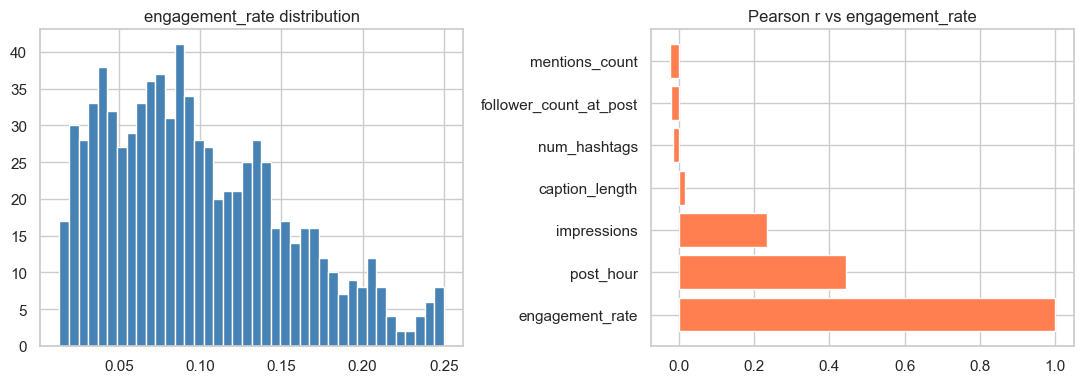

engagement_rate           1.000000
post_hour                 0.443744
impressions               0.233665
caption_length            0.015501
num_hashtags             -0.017450
follower_count_at_post   -0.022587
mentions_count           -0.023369
Name: engagement_rate, dtype: float64


In [19]:
# Ch. 6–8: exploration
target = pd.to_numeric(df_raw["engagement_rate"], errors="coerce")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(target.dropna(), bins=40, color="steelblue", edgecolor="white")
ax[0].set_title("engagement_rate distribution")
num_cols = ["post_hour", "num_hashtags", "mentions_count", "caption_length", "impressions", "follower_count_at_post"]
avail = [c for c in num_cols if c in df_raw.columns]
corr = df_raw[avail + ["engagement_rate"]].apply(pd.to_numeric, errors="coerce").corr()["engagement_rate"].sort_values(ascending=False)
ax[1].barh(corr.index.astype(str), corr.values, color="coral")
ax[1].set_title("Pearson r vs engagement_rate")
plt.tight_layout()
plt.show()
print(corr)


## 3. Feature engineering — actionable predictors only


In [20]:
# Single source of truth: ml_scripts/social_engagement_features.py
X, y, post_ids = get_x_y(df_raw)
print("Modeling rows:", len(X))
print("Feature columns:", list(X.columns))


Modeling rows: 812
Feature columns: ['platform', 'day_of_week', 'post_type', 'media_type', 'call_to_action_type', 'content_topic', 'post_hour', 'num_hashtags', 'mentions_count', 'caption_length', 'has_call_to_action', 'is_boosted']


## 4. Multiple linear regression (Ch. 9)


In [21]:
# Ch. 9: OLS
X_dm = sm.add_constant(pd.get_dummies(X, columns=CATEGORICAL, drop_first=True), has_constant="add")
ols = sm.OLS(y.astype(float), X_dm.astype(float)).fit()
print(ols.summary().tables[0])
print(ols.summary().tables[1])
print("R-squared:", ols.rsquared, "Adj. R-squared:", ols.rsquared_adj)


                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     7.312
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.16e-31
Time:                        23:20:34   Log-Likelihood:                 1320.2
No. Observations:                 812   AIC:                            -2562.
Df Residuals:                     773   BIC:                            -2379.
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## 5. Diagnostics (Ch. 10)


              feature       VIF
3      caption_length  7.964241
0           post_hour  4.336955
1        num_hashtags  3.238162
4  has_call_to_action  2.561564
2      mentions_count  1.489591
5          is_boosted  1.182043


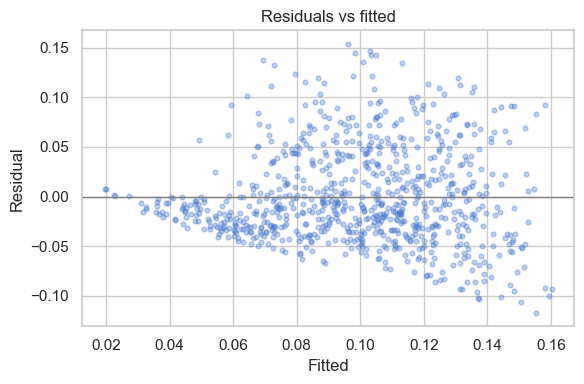

Durbin–Watson: 2.022338542342211


In [22]:
# Ch. 10: diagnostics
num_for_vif = X[[c for c in X.columns if c not in CATEGORICAL]].astype(float)
vif_df = pd.DataFrame({
    "feature": num_for_vif.columns,
    "VIF": [variance_inflation_factor(num_for_vif.values, i) for i in range(num_for_vif.shape[1])],
}).sort_values("VIF", ascending=False)
print(vif_df)

resid = ols.resid
fitted = ols.fittedvalues
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(fitted, resid, alpha=0.35, s=12)
ax.axhline(0, color="gray", lw=1)
ax.set_xlabel("Fitted")
ax.set_ylabel("Residual")
ax.set_title("Residuals vs fitted")
plt.tight_layout()
plt.show()
print("Durbin–Watson:", durbin_watson(resid))


## 6. Export `social_engagement_insights.json` for the .NET app


In [23]:
def friendly_name(col: str) -> str:
    return col.replace("_", " ").replace("T.", " = ").strip()


def resolve_seed_path() -> Path:
    cwd = Path.cwd().resolve()
    root = cwd.parent if cwd.name == "ml-pipeline" else cwd
    p = root / "backend" / "AngelsLandingv2.API" / "SeedData" / "social_engagement_insights.json"
    p.parent.mkdir(parents=True, exist_ok=True)
    return p


rows = []
for name, coef in ols.params.items():
    if name == "const":
        continue
    rows.append({
        "factorKey": name,
        "displayName": friendly_name(name),
        "coefficient": float(coef),
        "pValue": float(ols.pvalues.get(name, np.nan)),
    })
rows.sort(key=lambda r: abs(r["coefficient"]), reverse=True)
for i, r in enumerate(rows, start=1):
    r["rankOrder"] = i

now = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
payload = {
    "modelVersion": "ols_explanatory_v1",
    "computedAt": now,
    "caveats": (
        "Coefficients are associational (observational posts), not proof of causation. "
        "Interpret as conditional associations after controlling for other modeled fields."
    ),
    "olsR2": float(ols.rsquared),
    "olsAdjR2": float(ols.rsquared_adj),
    "factors": rows[:40],
}

out_path = resolve_seed_path()
out_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print("Wrote", out_path)
pd.DataFrame(rows).head(15)


Wrote /Users/zacharywaldrip/Intex2/AngelsLandingv2/backend/AngelsLandingv2.API/SeedData/social_engagement_insights.json


,factorKey,displayName,coefficient,pValue,rankOrder
0,has_call_to_action,has call to action,0.015535,0.000005,1
1,platform_Instagram,platform Instagram,0.013689,0.011992,2
2,platform_YouTube,platform YouTube,0.013220,0.080590,3
3,platform_LinkedIn,platform LinkedIn,0.012766,0.060256,4
4,call_to_action_type_ShareStory,call to action type ShareStory,0.012239,0.002762,5
5,is_boosted,is boosted,-0.010507,0.029527,6
6,content_topic_CampaignLaunch,content topic CampaignLaunch,0.010501,0.183490,7
7,content_topic_Gratitude,content topic Gratitude,-0.008938,0.243225,8
8,platform_Twitter,platform Twitter,0.008703,0.155284,9
9,platform_TikTok,platform TikTok,0.008629,0.272570,10
